# English League Dataset Cleaning

### Import Dataset

### **English League Datset Overview**

In [2]:
import pandas as pd

df = pd.read_csv("mydata.csv")

df.head()


,date,clock,stadium,class,attendance,Home Team,Goals Home,Away Team,Away Goals,home_possessions,...,away_duels,home_saves,away_saves,home_fouls,away_fouls,home_yellow,away_yellow,home_red,away_red,links
0,28th May 2023,4:30pm,Emirates Stadium,h,"60,095",2,5,13,0,51.0,...,52.2,0,3,8,11,0,0,0,0,https://www.skysports.com/football/arsenal-vs-...
1,28th May 2023,4:30pm,Villa Park,h,"42,212",7,2,6,1,40.3,...,47.8,3,3,15,16,4,4,0,0,https://www.skysports.com/football/aston-villa...
2,28th May 2023,4:30pm,Gtech Community Stadium,h,"17,120",9,1,1,0,34.4,...,50.0,2,3,12,8,4,0,0,0,https://www.skysports.com/football/brentford-v...
3,28th May 2023,4:30pm,Stamford Bridge,d,"40,130",12,1,4,1,64.4,...,45.5,3,5,9,11,0,0,0,0,https://www.skysports.com/football/chelsea-vs-...
4,28th May 2023,4:30pm,Selhurst Park,d,"25,198",11,1,16,1,66.0,...,41.7,3,2,9,13,0,2,0,0,https://www.skysports.com/football/crystal-pal...


### **Inspect the Data Structure**

In [3]:
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1140 entries, 0 to 1139
Data columns (total 40 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              1140 non-null   object 
 1   clock             1140 non-null   object 
 2   stadium           1140 non-null   object 
 3   class             1140 non-null   object 
 4   attendance        1140 non-null   object 
 5   Home Team         1140 non-null   int64  
 6   Goals Home        1140 non-null   int64  
 7   Away Team         1140 non-null   int64  
 8   Away Goals        1140 non-null   int64  
 9   home_possessions  1140 non-null   float64
 10  away_possessions  1140 non-null   float64
 11  home_shots        1140 non-null   int64  
 12  away_shots        1140 non-null   int64  
 13  home_on           1140 non-null   int64  
 14  away_on           1140 non-null   int64  
 15  home_off          1140 non-null   int64  
 16  away_off          1140 non-null   int64  


### **Check for Duplicate Rows**

In [4]:
df.duplicated().sum()

0

### **Standardize the column names**

#### *Column names before standardization*

In [5]:
df.columns

Index(['date', 'clock', 'stadium', 'class', 'attendance', 'Home Team',
       'Goals Home', 'Away Team', 'Away Goals', 'home_possessions',
       'away_possessions', 'home_shots', 'away_shots', 'home_on', 'away_on',
       'home_off', 'away_off', 'home_blocked', 'away_blocked', 'home_pass',
       'away_pass', 'home_chances', 'away_chances', 'home_corners',
       'away_corners', 'home_offside', 'away_offside', 'home_tackles',
       'away_tackles', 'home_duels', 'away_duels', 'home_saves', 'away_saves',
       'home_fouls', 'away_fouls', 'home_yellow', 'away_yellow', 'home_red',
       'away_red', 'links'],
      dtype='object')

#### *Column names after standardization*

In [6]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['date', 'clock', 'stadium', 'class', 'attendance', 'home_team',
       'goals_home', 'away_team', 'away_goals', 'home_possessions',
       'away_possessions', 'home_shots', 'away_shots', 'home_on', 'away_on',
       'home_off', 'away_off', 'home_blocked', 'away_blocked', 'home_pass',
       'away_pass', 'home_chances', 'away_chances', 'home_corners',
       'away_corners', 'home_offside', 'away_offside', 'home_tackles',
       'away_tackles', 'home_duels', 'away_duels', 'home_saves', 'away_saves',
       'home_fouls', 'away_fouls', 'home_yellow', 'away_yellow', 'home_red',
       'away_red', 'links'],
      dtype='object')

### **Convert 'date' to datetime**

In [18]:
# Convert 'date' to datetime
# The dataset contains mixed date formats:
# example: '15th August 2021' and '23/05/2021'
# dayfirst=True correctly reads the numeric dates as DD/MM/YYYY

df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

# verify conversion
df['date'].dtype


dtype('<M8[ns]')

In [19]:
# check for failed conversions
df['date'].isnull().sum()

0

#### *Extract Year*

In [20]:
df['year'] = df['date'].dt.year

#### *Extract Month*

In [21]:
df['month'] = df['date'].dt.month

#### *Extract Day*

In [22]:
df['day'] = df['date'].dt.day

#### *Create 'Season' Variable*

In [23]:
df['season'] = df['year'].astype(str) + "-" + (df['year'] + 1).astype(str)

##### Qucik verify of year, month,day,season columns

In [24]:
df[['date','year','month','day','season']].head()

,date,year,month,day,season
0,2023-05-28,2023,5,28,2023-2024
1,2023-05-28,2023,5,28,2023-2024
2,2023-05-28,2023,5,28,2023-2024
3,2023-05-28,2023,5,28,2023-2024
4,2023-05-28,2023,5,28,2023-2024


In [25]:
df[['date','year','month','day','season']].tail()

,date,year,month,day,season
1135,2020-09-13,2020,9,13,2020-2021
1136,2020-12-09,2020,12,9,2020-2021
1137,2020-12-09,2020,12,9,2020-2021
1138,2020-12-09,2020,12,9,2020-2021
1139,2020-12-09,2020,12,9,2020-2021


### **Clean 'attendance'**

In [13]:
df['attendance'] = df['attendance'].str.replace(',', '', regex=False)
df['attendance'] = pd.to_numeric(df['attendance'], errors='coerce')

# verify conversion
df['attendance'].dtype

dtype('int64')

### **Convert home_team and away_team from numerical to categorical** - ***LOGISTIC REGRESSION MODELING ONLY/ NOT NEEDED FOR RANDOM FOREST OR XGBOOST MODELING!***

In [8]:
df['home_team'] = df['home_team'].astype('category')
df['away_team'] = df['away_team'].astype('category')

#### *Then one-hot encode* (Only before modeling)

In [ ]:
df = pd.get_dummies(df, columns=['home_team', 'away_team'], drop_first=True)

### **Drop the 'links' column**

In [14]:
df = df.drop(columns=['links'])

### **Inspect the class column**

In [15]:
df['class'].value_counts()

h    494
a    390
d    256
Name: class, dtype: int64

***Not sure if we want to keep this or drop the 'class' variable due to it containing match outcomes, and can thus lead to data leakage. We would need to drop home_goals and away_goals from predictors to prevent data leakage. Or we could drop class alltogether - Will leave this to the discretion of whoever is perfroming predictive modeling***

#### *Code to Drop Class if needed (Optional)*

In [ ]:
df = df.drop(columns=['class'])

### **Final cleaning check**

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1140 entries, 0 to 1139
Data columns (total 43 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              1140 non-null   datetime64[ns]
 1   clock             1140 non-null   object        
 2   stadium           1140 non-null   object        
 3   class             1140 non-null   object        
 4   attendance        1140 non-null   int64         
 5   home_team         1140 non-null   int64         
 6   goals_home        1140 non-null   int64         
 7   away_team         1140 non-null   int64         
 8   away_goals        1140 non-null   int64         
 9   home_possessions  1140 non-null   float64       
 10  away_possessions  1140 non-null   float64       
 11  home_shots        1140 non-null   int64         
 12  away_shots        1140 non-null   int64         
 13  home_on           1140 non-null   int64         
 14  away_on           1140 n

### **Create target variables (for predictive modeling)**

#### *Predicting match outcomes:* 'result' target variable

In [17]:
df['result'] = df.apply(
    lambda x: 'home_win' if x['goals_home'] > x['away_goals']
    else ('away_win' if x['goals_home'] < x['away_goals'] else 'draw'),
    axis=1
)

# Or encode:
df['result_encoded'] = df['result'].map({
    'home_win': 0,
    'draw': 1,
    'away_win': 2
})

#### *Tests home advantage:* Home_Win_Binary

In [18]:
df['home_win_binary'] = (df['goals_home'] > df['away_goals']).astype(int)

#### *Analyze away team performance:* Away_Win_Binary

In [19]:
df['away_win_binary'] = (df['away_goals'] > df['goals_home']).astype(int)

#### *Predict draws:* Draw_Binary

In [20]:
df['draw_binary'] = (df['goals_home'] == df['away_goals']).astype(int)

#### *Supports performance analysis:* Close_Match (Competitiveness)

In [21]:
df['close_match'] = (abs(df['goals_home'] - df['away_goals']) <= 1).astype(int)

### **Create Difference Feaures**

#### *Tests whether higher possesions lead to winning:* Possesion_Difference

In [22]:
df['possession_diff'] = df['home_possessions'] - df['away_possessions']

#### *Tests attacking performance:* Shots_Difference

In [23]:
df['shots_diff'] = df['home_shots'] - df['away_shots']

#### *Tests Shots on Target:* Shots_On_Target_Difference

In [24]:
df['shots_on_target_diff'] = df['home_on'] - df['away_on']

#### *Tests Fouls (Discipline):* Fouls_Difference

In [25]:
df['fouls_diff'] = df['home_fouls'] - df['away_fouls']

#### *Analyzes Discipline Impact:* Yellow_Difference, Red_Difference

In [26]:
df['yellow_diff'] = df['home_yellow'] - df['away_yellow']
df['red_diff'] = df['home_red'] - df['away_red']

#### *Tests if Higher Stadium Attendence Improves Home Performance:* Attendence_High, Attendence_Home_Advanatge 

In [27]:
df['attendance_high'] = (df['attendance'] > df['attendance'].median()).astype(int)

# OR also this which interacts with home wins:

df['attendance_home_advantage'] = df['attendance'] * df['home_win_binary']

#### *Analyzes Perfromance Strength:* Goal_Difference

In [28]:
df['goal_diff'] = df['goals_home'] - df['away_goals']

# Descriptive Analysis of English League Dataset

In [29]:
# Print matches per year
df['year'].value_counts().sort_index()

2020    155
2021    408
2022    361
2023    216
Name: year, dtype: int64

## Overall summary of numeric variables

In [30]:
df.describe()

,attendance,home_team,goals_home,away_team,away_goals,home_possessions,away_possessions,home_shots,away_shots,home_on,...,close_match,possession_diff,shots_diff,shots_on_target_diff,fouls_diff,yellow_diff,red_diff,attendance_high,attendance_home_advantage,goal_diff
count,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,...,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000
mean,26584.311404,11.450000,1.502632,11.450000,1.290351,50.816754,49.205965,13.558772,11.474561,4.715789,...,0.601754,1.610789,2.084211,0.676316,0.052632,-0.135088,-0.001754,0.500000,13482.674561,0.212281
std,22827.967261,6.815784,1.359450,6.815784,1.233457,12.896181,12.899495,5.615658,5.048515,2.564688,...,0.489751,25.780092,9.009697,3.839351,4.556045,1.617832,0.332596,0.500219,22251.766741,1.940879
min,0.000000,1.000000,0.000000,1.000000,0.000000,17.900000,17.600000,1.000000,1.000000,0.000000,...,0.000000,-64.200000,-25.000000,-13.000000,-17.000000,-5.000000,-2.000000,0.000000,0.000000,-7.000000
25%,0.000000,5.750000,0.750000,5.750000,0.000000,40.900000,39.100000,9.000000,8.000000,3.000000,...,0.000000,-18.200000,-4.000000,-2.000000,-3.000000,-1.000000,0.000000,0.000000,0.000000,-1.000000
50%,29288.500000,11.000000,1.000000,11.000000,1.000000,50.850000,49.200000,13.000000,11.000000,5.000000,...,1.000000,1.700000,2.000000,1.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000
75%,41889.250000,17.250000,2.000000,17.250000,2.000000,60.900000,59.125000,17.000000,15.000000,6.000000,...,1.000000,21.800000,8.000000,3.000000,3.000000,1.000000,0.000000,1.000000,29316.500000,1.000000
max,75546.000000,25.000000,9.000000,25.000000,7.000000,82.400000,82.100000,33.000000,31.000000,15.000000,...,1.000000,64.800000,28.000000,13.000000,14.000000,6.000000,2.000000,1.000000,75546.000000,9.000000


## Compare home vs away averages

In [31]:
print("Average home goals:", df['goals_home'].mean())
print("Average away goals:", df['away_goals'].mean())

print("Average home possession:", df['home_possessions'].mean())
print("Average away possession:", df['away_possessions'].mean())

print("Average home shots:", df['home_shots'].mean())
print("Average away shots:", df['away_shots'].mean())

Average home goals: 1.5026315789473683
Average away goals: 1.2903508771929824
Average home possession: 50.81675438596492
Average away possession: 49.2059649122807
Average home shots: 13.55877192982456
Average away shots: 11.474561403508773



Do home teams score more?

Do home teams have higher possession?

Do home teams take more shots?

## Match Outcome Distribution

In [33]:
def get_result(row):
    if row['goals_home'] > row['away_goals']:
        return 'Home Win'
    elif row['goals_home'] < row['away_goals']:
        return 'Away Win'
    else:
        return 'Draw'

df['match_result'] = df.apply(get_result, axis=1)

df['match_result'].value_counts()

df['match_result'].value_counts(normalize=True) * 100

Home Win    43.157895
Away Win    34.298246
Draw        22.543860
Name: match_result, dtype: float64

percent of matches won by home teams

percent won by away teams

percent ending in draws

## Variable Distributions

### *Distribution of Home Goals*

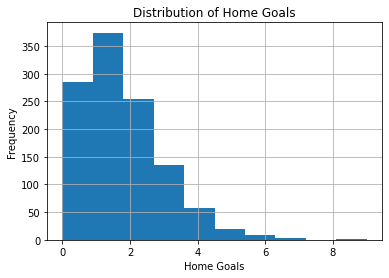

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

df['goals_home'].hist()
plt.title("Distribution of Home Goals")
plt.xlabel("Home Goals")
plt.ylabel("Frequency")
plt.show()

### *Distribution of Away Goals*

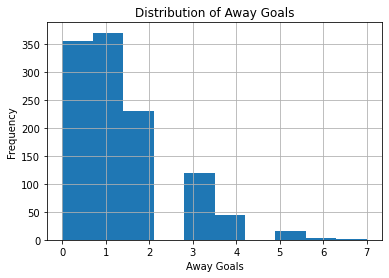

In [36]:
df['away_goals'].hist()
plt.title("Distribution of Away Goals")
plt.xlabel("Away Goals")
plt.ylabel("Frequency")
plt.show()

### *Distribtuion of Satidium Attendance*

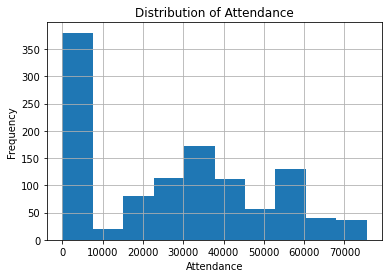

In [37]:
df['attendance'].hist()
plt.title("Distribution of Attendance")
plt.xlabel("Attendance")
plt.ylabel("Frequency")
plt.show()

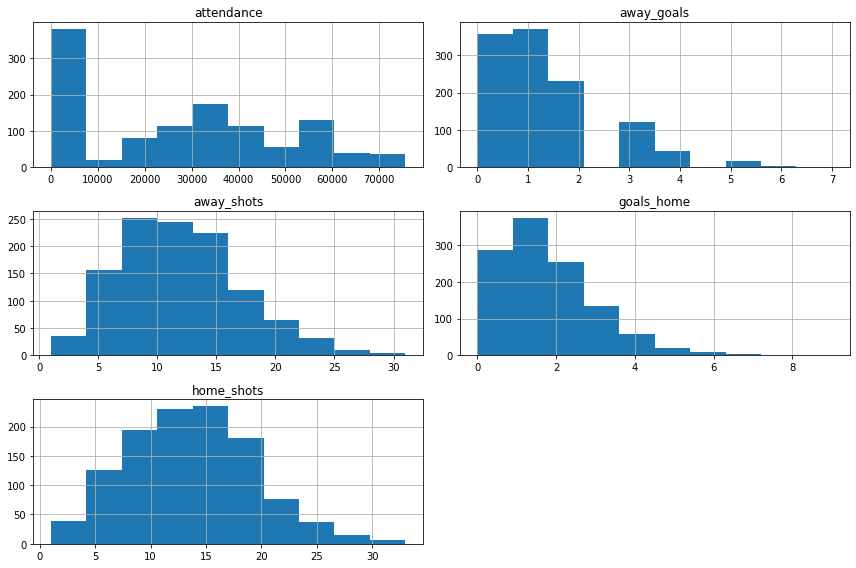

In [38]:
df[['goals_home', 'away_goals', 'home_shots', 'away_shots', 'attendance']].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

whether variables are skewed

whether most matches cluster around certain values

whether there are extreme observations

## Goals Distribution

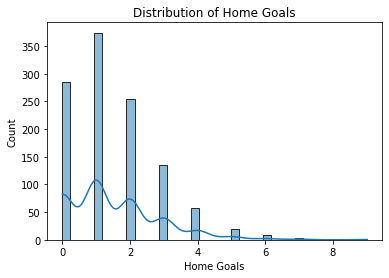

In [39]:
sns.histplot(df['goals_home'], kde=True)
plt.title("Distribution of Home Goals")
plt.xlabel("Home Goals")
plt.show()

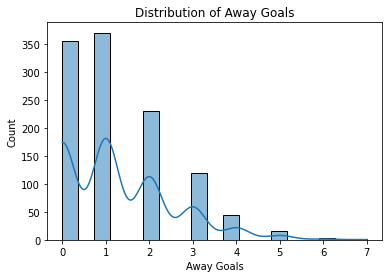

In [40]:
sns.histplot(df['away_goals'], kde=True)
plt.title("Distribution of Away Goals")
plt.xlabel("Away Goals")
plt.show()

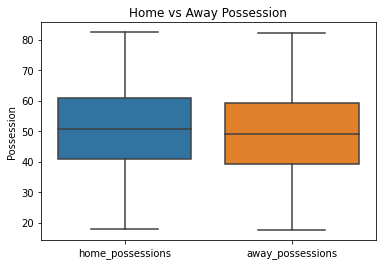

In [41]:
possession_df = df[['home_possessions', 'away_possessions']]

sns.boxplot(data=possession_df)
plt.title("Home vs Away Possession")
plt.ylabel("Possession")
plt.show()

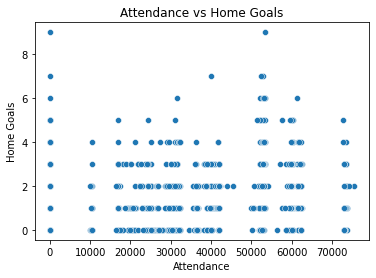

In [42]:
sns.scatterplot(x='attendance', y='goals_home', data=df)
plt.title("Attendance vs Home Goals")
plt.xlabel("Attendance")
plt.ylabel("Home Goals")
plt.show()

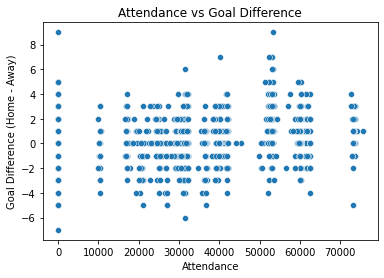

In [43]:
df['goal_diff'] = df['goals_home'] - df['away_goals']

sns.scatterplot(x='attendance', y='goal_diff', data=df)
plt.title("Attendance vs Goal Difference")
plt.xlabel("Attendance")
plt.ylabel("Goal Difference (Home - Away)")
plt.show()

## Correlation analysis

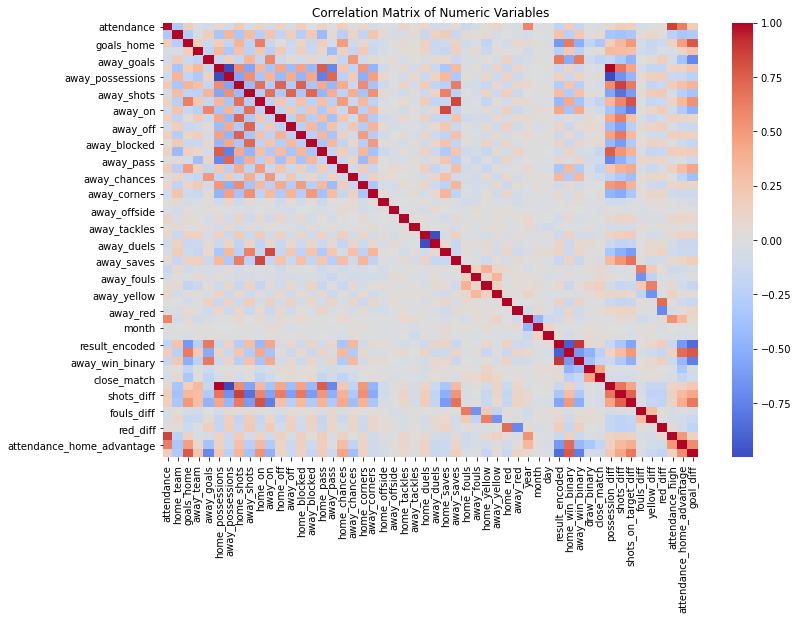

In [46]:
import pandas as pd
import numpy as np

corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Matrix of Numeric Variables")
plt.show()

## Focus on variables related to scoring

In [47]:
corr['goals_home'].sort_values(ascending=False)

goals_home                   1.000000
goal_diff                    0.775754
home_win_binary              0.634342
home_on                      0.621186
shots_on_target_diff         0.507236
home_chances                 0.482039
attendance_home_advantage    0.476189
home_shots                   0.354652
shots_diff                   0.336667
away_team                    0.186964
possession_diff              0.185196
home_possessions             0.184580
attendance                   0.175029
home_pass                    0.171819
away_saves                   0.142630
attendance_high              0.138791
home_duels                   0.134668
home_blocked                 0.116458
home_corners                 0.089137
away_red                     0.085561
home_tackles                 0.068596
year                         0.054737
home_off                     0.038499
away_offside                 0.036226
month                        0.016543
away_yellow                  0.006982
away_tackles

In [48]:
corr['away_goals'].sort_values(ascending=False)

away_goals                   1.000000
away_win_binary              0.649679
result_encoded               0.649485
away_on                      0.593359
away_chances                 0.502976
away_shots                   0.345273
home_team                    0.178167
red_diff                     0.168171
away_possessions             0.156701
home_red                     0.140000
away_pass                    0.118755
away_blocked                 0.093459
home_saves                   0.084757
yellow_diff                  0.061909
away_duels                   0.056479
away_off                     0.053510
away_corners                 0.048788
home_yellow                  0.033637
away_tackles                 0.026717
away_offside                 0.025585
month                        0.023697
home_offside                 0.013410
day                          0.002925
fouls_diff                  -0.006003
away_fouls                  -0.033961
year                        -0.039239
home_fouls  

## Home_Win_Binary Correlation

In [49]:
corr['home_win_binary'].sort_values(ascending=False)

home_win_binary              1.000000
goal_diff                    0.778298
attendance_home_advantage    0.695676
goals_home                   0.634342
shots_on_target_diff         0.503603
home_on                      0.421304
home_chances                 0.323291
shots_diff                   0.306701
home_shots                   0.239187
away_team                    0.229700
attendance                   0.177801
attendance_high              0.141684
possession_diff              0.128102
home_possessions             0.126999
home_pass                    0.124883
away_saves                   0.121243
home_duels                   0.120110
away_red                     0.087438
home_blocked                 0.082303
year                         0.081614
home_corners                 0.079857
home_tackles                 0.067684
away_fouls                   0.024272
home_off                     0.020886
away_offside                 0.017500
away_yellow                  0.010219
away_tackles

which variables are associated with home wins

which variables are associated with higher scoring

which features may be useful later in modeling

## Outlier Check

# Random Forest - Practice

Accuracy: 0.6403508771929824
Confusion Matrix:
 [[96 34]
 [48 50]]
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.74      0.70       130
           1       0.60      0.51      0.55        98

    accuracy                           0.64       228
   macro avg       0.63      0.62      0.63       228
weighted avg       0.64      0.64      0.64       228

ROC AUC: 0.7157378335949764


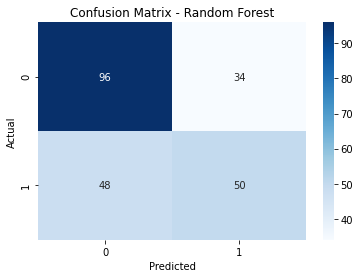

            feature  importance
3        away_shots    0.152000
8        attendance    0.144224
2        home_shots    0.121025
0  home_possessions    0.118340
1  away_possessions    0.116117
5        away_fouls    0.094539
4        home_fouls    0.089129
7      away_corners    0.084048
6      home_corners    0.080577


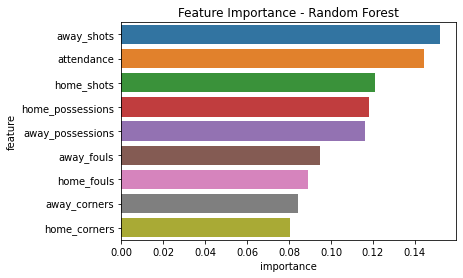

In [56]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    'home_possessions',
    'away_possessions',
    'home_shots',
    'away_shots',
    'home_fouls',
    'away_fouls',
    'home_corners',
    'away_corners',
    'attendance'
]
X = df[features]
y = df['home_win_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=None
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y_test, y_pred))
auc = roc_auc_score(y_test, y_pred_prob)
print("ROC AUC:", auc)

# Plot of confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Plot feature importance
importances = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importances)
sns.barplot(data=importances, x='importance', y='feature')
plt.title("Feature Importance - Random Forest")
plt.show()
